<a href="https://colab.research.google.com/github/Aksh6472/ML-data-analytics-/blob/main/Energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#T1

In [37]:
import pandas as pd
import numpy as np

# -----------------------------------------------------------------------
# 1. LOAD THE DATA
# -----------------------------------------------------------------------
INPUT_FILE = "/content/Energy consumption with nulls.csv"

df = pd.read_csv(INPUT_FILE)

In [38]:
print("=" * 60)
print("STEP 1: Raw data overview")
print("=" * 60)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nColumn data types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())

STEP 1: Raw data overview
Shape: 1000 rows, 11 columns

Column data types:
Timestamp             object
Temperature          float64
Humidity             float64
SquareFootage        float64
Occupancy            float64
HVACUsage             object
LightingUsage         object
RenewableEnergy      float64
DayOfWeek             object
Holiday               object
EnergyConsumption    float64
dtype: object

First 5 rows:
          Timestamp  Temperature   Humidity  SquareFootage  Occupancy  \
0  01-01-2022 00:00    25.139433  43.431581    1565.693999        5.0   
1  01-01-2022 01:00    27.731651  54.225919    1411.064918        1.0   
2  01-01-2022 02:00    28.704277  58.907658    1755.715009        2.0   
3  01-01-2022 03:00    20.080469  50.371637    1452.316318        1.0   
4  01-01-2022 04:00    23.097359  51.401421    1094.130359        9.0   

  HVACUsage LightingUsage  RenewableEnergy  DayOfWeek Holiday  \
0        On           Off         2.774699     Monday      No   
1       

In [39]:
# 2. DIAGNOSE MISSING VALUES
print("\n" + "=" * 60)
print("STEP 2: Missing value report")
print("=" * 60)
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
})
print(missing_report[missing_report["missing_count"] > 0])


STEP 2: Missing value report
                 missing_count  missing_pct
Temperature                 50          5.0
Humidity                    50          5.0
SquareFootage               50          5.0
Occupancy                   50          5.0
HVACUsage                   50          5.0
LightingUsage               50          5.0
RenewableEnergy             50          5.0
DayOfWeek                   50          5.0
Holiday                     50          5.0


In [40]:
#3. HANDLE MISSING VALUES

print("\n" + "=" * 60)
print("STEP 3: Handling missing values")
print("=" * 60)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols.remove("Timestamp")  # Timestamp is text but not "categorical"

print(f"Numeric columns (median fill): {numeric_cols}")
print(f"Categorical columns (mode fill): {categorical_cols}")

for col in numeric_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  Filled '{col}' nulls with median = {median_val:.2f}")

for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"  Filled '{col}' nulls with mode = '{mode_val}'")

print(f"\nRemaining nulls after cleaning: {df.isnull().sum().sum()}")


STEP 3: Handling missing values
Numeric columns (median fill): ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'RenewableEnergy', 'EnergyConsumption']
Categorical columns (mode fill): ['HVACUsage', 'LightingUsage', 'DayOfWeek', 'Holiday']
  Filled 'Temperature' nulls with median = 24.75
  Filled 'Humidity' nulls with median = 45.80
  Filled 'SquareFootage' nulls with median = 1507.77
  Filled 'Occupancy' nulls with median = 5.00
  Filled 'RenewableEnergy' nulls with median = 15.03
  Filled 'HVACUsage' nulls with mode = 'Off'
  Filled 'LightingUsage' nulls with mode = 'Off'
  Filled 'DayOfWeek' nulls with mode = 'Friday'
  Filled 'Holiday' nulls with mode = 'No'

Remaining nulls after cleaning: 0


In [41]:
# 4. FEATURE ENGINEERING FROM TIMESTAMP
print("\n" + "=" * 60)
print("STEP 4: Feature engineering from Timestamp")
print("=" * 60)

df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%d-%m-%Y %H:%M")
df["Hour"] = df["Timestamp"].dt.hour
df["Month"] = df["Timestamp"].dt.month
print("Added 'Hour' and 'Month' columns extracted from Timestamp.")


STEP 4: Feature engineering from Timestamp
Added 'Hour' and 'Month' columns extracted from Timestamp.


In [42]:
#5. ENCODE CATEGORICAL VARIABLES

print("\n" + "=" * 60)
print("STEP 5: Encoding categorical variables")
print("=" * 60)

binary_maps = {
    "HVACUsage": {"On": 1, "Off": 0},
    "LightingUsage": {"On": 1, "Off": 0},
    "Holiday": {"Yes": 1, "No": 0}
}
for col, mapping in binary_maps.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
        print(f"  Encoded '{col}' as binary (1/0)")
    else:
        print(f"  Warning: Column '{col}' not found for binary encoding.")

# Check if 'DayOfWeek' column exists before attempting one-hot encoding
if "DayOfWeek" in df.columns:
    df = pd.get_dummies(df, columns=["DayOfWeek"], prefix="Day", drop_first=True)
    print("  One-hot encoded 'DayOfWeek' (drop_first=True to avoid redundancy)")
else:
    print("  Warning: 'DayOfWeek' column not found for one-hot encoding.")

# Drop the raw Timestamp now that we've extracted Hour/Month from it
if "Timestamp" in df.columns:
    df = df.drop(columns=["Timestamp"])
else:
    print("  Warning: 'Timestamp' column not found for dropping.")


STEP 5: Encoding categorical variables
  Encoded 'HVACUsage' as binary (1/0)
  Encoded 'LightingUsage' as binary (1/0)
  Encoded 'Holiday' as binary (1/0)
  One-hot encoded 'DayOfWeek' (drop_first=True to avoid redundancy)


In [45]:
OUTPUT_FILE = "/content/cleaned_energy_data.csv"

# 6. SAVE CLEANED DATASET

print("\n" + "=" * 60)
print("STEP 6: Saving cleaned dataset")
print("=" * 60)
print(f"Final shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Final columns: {list(df.columns)}")

df.to_csv(OUTPUT_FILE, index=False)
print(f"\nSaved cleaned data to '{OUTPUT_FILE}'")
print("This file is used as input for T2 (linear regression).")


STEP 6: Saving cleaned dataset
Final shape: 1000 rows, 17 columns
Final columns: ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'HVACUsage', 'LightingUsage', 'RenewableEnergy', 'Holiday', 'EnergyConsumption', 'Hour', 'Month', 'Day_Monday', 'Day_Saturday', 'Day_Sunday', 'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday']

Saved cleaned data to '/content/cleaned_energy_data.csv'
This file is used as input for T2 (linear regression).


#T2: Building programs to work with linear regression in Python

In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [47]:
INPUT_FILE = "/content/cleaned_energy_data.csv"
df = pd.read_csv(INPUT_FILE)

print("=" * 60)
print("STEP 1: Cleaned data overview")
print("=" * 60)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nColumns:", list(df.columns))

STEP 1: Cleaned data overview
Shape: 1000 rows, 17 columns

Columns: ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'HVACUsage', 'LightingUsage', 'RenewableEnergy', 'Holiday', 'EnergyConsumption', 'Hour', 'Month', 'Day_Monday', 'Day_Saturday', 'Day_Sunday', 'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday']


In [49]:
print("\n" + "=" * 60)
print("STEP 2: Splitting features and target")
print("=" * 60)
TARGET = "EnergyConsumption"
X = df.drop(columns=[TARGET])
y = df[TARGET]
print(f"Target: {TARGET}")
print(f"Features ({X.shape[1]}): {list(X.columns)}")


STEP 2: Splitting features and target
Target: EnergyConsumption
Features (16): ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'HVACUsage', 'LightingUsage', 'RenewableEnergy', 'Holiday', 'Hour', 'Month', 'Day_Monday', 'Day_Saturday', 'Day_Sunday', 'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday']


In [51]:
print("\n" + "=" * 60)
print("STEP 3: Train/test split")
print("=" * 60)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train set: {X_train.shape[0]} rows")
print(f"Test set:  {X_test.shape[0]} rows")


STEP 3: Train/test split
Train set: 800 rows
Test set:  200 rows


In [53]:
print("\n" + "=" * 60)
print("STEP 4: Training Linear Regression model")
print("=" * 60)
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained.")


STEP 4: Training Linear Regression model
Model trained.


In [55]:
print("\n" + "=" * 60)
print("STEP 5: Making predictions on test set")
print("=" * 60)
y_pred = model.predict(X_test)
print("Sample predictions vs actual:")
comparison = pd.DataFrame({"Actual": y_test.values[:5], "Predicted": y_pred[:5]})
print(comparison)


STEP 5: Making predictions on test set
Sample predictions vs actual:
      Actual  Predicted
0  86.920611  81.423266
1  88.351606  76.289268
2  79.431363  75.364059
3  90.009188  78.029321
4  83.891100  80.601233


In [57]:
print("\n" + "=" * 60)
print("STEP 6: Model evaluation")
print("=" * 60)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MAE  (Mean Absolute Error) : {mae:.3f}")
print(f"MSE  (Mean Squared Error)  : {mse:.3f}")
print(f"RMSE (Root Mean Sq. Error) : {rmse:.3f}")
print(f"R2   (R-squared)           : {r2:.3f}")


STEP 6: Model evaluation
MAE  (Mean Absolute Error) : 4.647
MSE  (Mean Squared Error)  : 33.871
RMSE (Root Mean Sq. Error) : 5.820
R2   (R-squared)           : 0.483


In [60]:
print("\n" + "=" * 60)
print("STEP 7: Feature coefficients")
print("=" * 60)
coefficients = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(coefficients)
print(f"\nIntercept: {model.intercept_:.3f}")
print("\nThis model is used as input for T3 (cross validation).")


STEP 7: Feature coefficients
HVACUsage          4.150685
Temperature        1.993818
LightingUsage      1.358832
Day_Saturday       0.860682
Holiday            0.749477
Day_Tuesday        0.721845
Day_Thursday       0.605288
Day_Sunday         0.597319
Occupancy          0.515066
Day_Monday         0.504565
Month              0.492837
Day_Wednesday      0.139452
RenewableEnergy    0.100094
Humidity          -0.040913
Hour              -0.033419
SquareFootage     -0.000243
dtype: float64

Intercept: 21.970

This model is used as input for T3 (cross validation).


T3: cross validation

In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
INPUT_FILE = "/content/cleaned_energy_data.csv"
df = pd.read_csv(INPUT_FILE)

print("=" * 60)
print("STEP 1: Cleaned data overview")
print("=" * 60)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

STEP 1: Cleaned data overview
Shape: 1000 rows, 17 columns


In [63]:
print("\n" + "=" * 60)
print("STEP 2: Splitting features and target")
print("=" * 60)
TARGET = "EnergyConsumption"
X = df.drop(columns=[TARGET])
y = df[TARGET]
print(f"Target: {TARGET}")
print(f"Features ({X.shape[1]}): {list(X.columns)}")


STEP 2: Splitting features and target
Target: EnergyConsumption
Features (16): ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'HVACUsage', 'LightingUsage', 'RenewableEnergy', 'Holiday', 'Hour', 'Month', 'Day_Monday', 'Day_Saturday', 'Day_Sunday', 'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday']


In [64]:
print("\n" + "=" * 60)
print("STEP 3: Setting up K-Fold cross validation")
print("=" * 60)
K = 5
kfold = KFold(n_splits=K, shuffle=True, random_state=42)
print(f"Number of folds: {K}")

model = LinearRegression()


STEP 3: Setting up K-Fold cross validation
Number of folds: 5


In [66]:
print("\n" + "=" * 60)
print("STEP 4: Cross validation - R2 score per fold")
print("=" * 60)
r2_scores = cross_val_score(model, X, y, cv=kfold, scoring="r2")
for i, score in enumerate(r2_scores, start=1):
    print(f"  Fold {i}: R2 = {score:.3f}")
print(f"\nMean R2 : {r2_scores.mean():.3f}")
print(f"Std  R2 : {r2_scores.std():.3f}")



STEP 4: Cross validation - R2 score per fold
  Fold 1: R2 = 0.483
  Fold 2: R2 = 0.625
  Fold 3: R2 = 0.623
  Fold 4: R2 = 0.503
  Fold 5: R2 = 0.606

Mean R2 : 0.568
Std  R2 : 0.062


In [68]:
print("\n" + "=" * 60)
print("STEP 5: Cross validation - MAE per fold")
print("=" * 60)
mae_scores = -cross_val_score(model, X, y, cv=kfold, scoring="neg_mean_absolute_error")
for i, score in enumerate(mae_scores, start=1):
    print(f"  Fold {i}: MAE = {score:.3f}")
print(f"\nMean MAE : {mae_scores.mean():.3f}")
print(f"Std  MAE : {mae_scores.std():.3f}")


STEP 5: Cross validation - MAE per fold
  Fold 1: MAE = 4.647
  Fold 2: MAE = 4.089
  Fold 3: MAE = 4.037
  Fold 4: MAE = 4.245
  Fold 5: MAE = 4.379

Mean MAE : 4.279
Std  MAE : 0.219


In [70]:
print("\n" + "=" * 60)
print("STEP 6: Cross validation - RMSE per fold")
print("=" * 60)
mse_scores = -cross_val_score(model, X, y, cv=kfold, scoring="neg_mean_squared_error")
rmse_scores = np.sqrt(mse_scores)
for i, score in enumerate(rmse_scores, start=1):
    print(f"  Fold {i}: RMSE = {score:.3f}")
print(f"\nMean RMSE : {rmse_scores.mean():.3f}")
print(f"Std  RMSE : {rmse_scores.std():.3f}")


STEP 6: Cross validation - RMSE per fold
  Fold 1: RMSE = 5.820
  Fold 2: RMSE = 5.131
  Fold 3: RMSE = 4.882
  Fold 4: RMSE = 5.330
  Fold 5: RMSE = 5.383

Mean RMSE : 5.309
Std  RMSE : 0.310


In [71]:
print("\n" + "=" * 60)
print("STEP 7: Summary")
print("=" * 60)
summary = pd.DataFrame({
    "R2": r2_scores,
    "MAE": mae_scores,
    "RMSE": rmse_scores
}, index=[f"Fold {i}" for i in range(1, K + 1)])
print(summary)
print("\nAverages:")
print(summary.mean())
print("\nA small std across folds means the model performs consistently")
print("on different subsets of data (i.e. it is not overfitting to one split).")


STEP 7: Summary
              R2       MAE      RMSE
Fold 1  0.482890  4.646625  5.819846
Fold 2  0.624663  4.089107  5.131395
Fold 3  0.623260  4.037055  4.882109
Fold 4  0.503415  4.245306  5.330196
Fold 5  0.606133  4.378557  5.383178

Averages:
R2      0.568072
MAE     4.279330
RMSE    5.309345
dtype: float64

A small std across folds means the model performs consistently
on different subsets of data (i.e. it is not overfitting to one split).


#T4:Building programs to performance metrics in python

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [73]:
# Reuse the multi-feature model setup
X = df.drop(columns=['EnergyConsumption'])
y = df['EnergyConsumption']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

In [75]:
# ---- Performance metrics computed manually (from scratch) ----
n = len(y_test)

manual_mse  = np.sum((y_test - y_pred) ** 2) / n
manual_mae  = np.sum(np.abs(y_test - y_pred)) / n
manual_rmse = np.sqrt(manual_mse)

ss_res = np.sum((y_test - y_pred) ** 2)        # residual sum of squares (unexplained variance)
ss_tot = np.sum((y_test - y_test.mean()) ** 2) # total variance in actual values
manual_r2 = 1 - (ss_res / ss_tot)

print("----- Manually Computed Metrics -----")
print(f"MSE  : {manual_mse:.4f}")
print(f"RMSE : {manual_rmse:.4f}")
print(f"MAE  : {manual_mae:.4f}")
print(f"R²   : {manual_r2:.4f}")

----- Manually Computed Metrics -----
MSE  : 33.8706
RMSE : 5.8198
MAE  : 4.6466
R²   : 0.4829


In [77]:
# ---- Same metrics computed using sklearn (to cross-check the manual math) ----
sklearn_mse  = mean_squared_error(y_test, y_pred)
sklearn_rmse = np.sqrt(sklearn_mse)
sklearn_mae  = mean_absolute_error(y_test, y_pred)
sklearn_r2   = r2_score(y_test, y_pred)

print("----- sklearn Metrics -----")
print(f"MSE  : {sklearn_mse:.4f}")
print(f"RMSE : {sklearn_rmse:.4f}")
print(f"MAE  : {sklearn_mae:.4f}")
print(f"R²   : {sklearn_r2:.4f}")


----- sklearn Metrics -----
MSE  : 33.8706
RMSE : 5.8198
MAE  : 4.6466
R²   : 0.4829


In [79]:
# Sanity check: manual and sklearn values should match exactly
print("\nMatch check -> MSE:", np.isclose(manual_mse, sklearn_mse),
      "| MAE:", np.isclose(manual_mae, sklearn_mae),
      "| R²:", np.isclose(manual_r2, sklearn_r2))


Match check -> MSE: True | MAE: True | R²: True


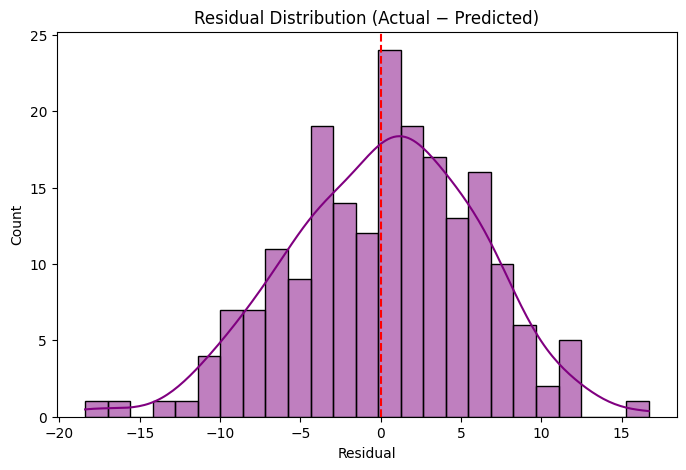

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Visualize residuals (errors) to check if the model's mistakes are random or patterned ----
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True, bins=25, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residual Distribution (Actual − Predicted)')
plt.xlabel('Residual')
plt.show()

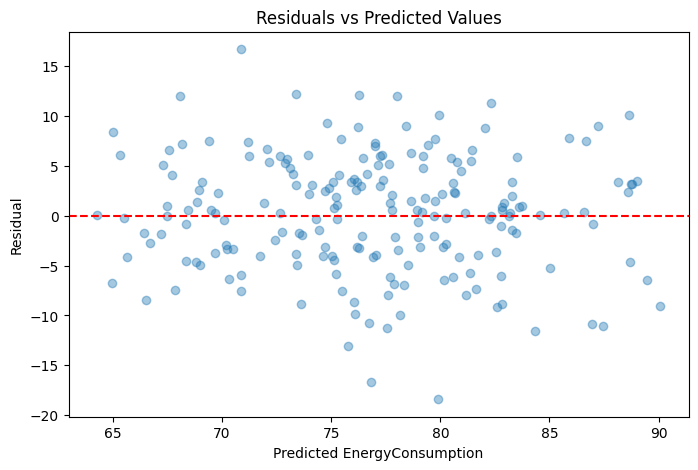

In [83]:
# ---- Residuals vs Predicted values plot ----
# A good model shows residuals scattered randomly around 0, with no visible pattern/funnel shape
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted EnergyConsumption')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted Values')
plt.show()

In [86]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Using ALL available features together (multiple linear regression)
X = df.drop(columns=['EnergyConsumption'])
y = df['EnergyConsumption']

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [88]:
# Fit the multivariable model
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

y_pred_multi = multi_model.predict(X_test)

print(f"Intercept (β0): {multi_model.intercept_:.4f}")
print(f"R² Score       : {r2_score(y_test, y_pred_multi):.4f}")

Intercept (β0): 77.0140
R² Score       : 0.4829


In [90]:
# ---- Inspect each feature's coefficient (β) ----
# Coefficient = how much EnergyConsumption changes for a 1-unit change in that (scaled) feature,
# holding all other features constant
coeff_table = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Coefficient (β)': multi_model.coef_
}).sort_values(by='Coefficient (β)', key=abs, ascending=False)

coeff_table

,Feature,Coefficient (β)
0,Temperature,5.557715
4,HVACUsage,2.071088
3,Occupancy,1.428579
6,RenewableEnergy,0.848206
5,LightingUsage,0.678023
7,Holiday,0.372120
1,Humidity,-0.340680
11,Day_Saturday,0.296849
14,Day_Tuesday,0.245898
8,Hour,-0.230909


In [92]:
# ---- Compare: single-variable model vs multi-variable model ----
best_single_feature = 'Temperature'   # identified as strongest single predictor earlier (T2)

single_model = LinearRegression().fit(X_train[[best_single_feature]], y_train)
single_pred = single_model.predict(X_test[[best_single_feature]])

print(f"Single-variable ({best_single_feature}) R² : {r2_score(y_test, single_pred):.4f}")
print(f"Multi-variable (all features) R²          : {r2_score(y_test, y_pred_multi):.4f}")


Single-variable (Temperature) R² : 0.3631
Multi-variable (all features) R²          : 0.4829


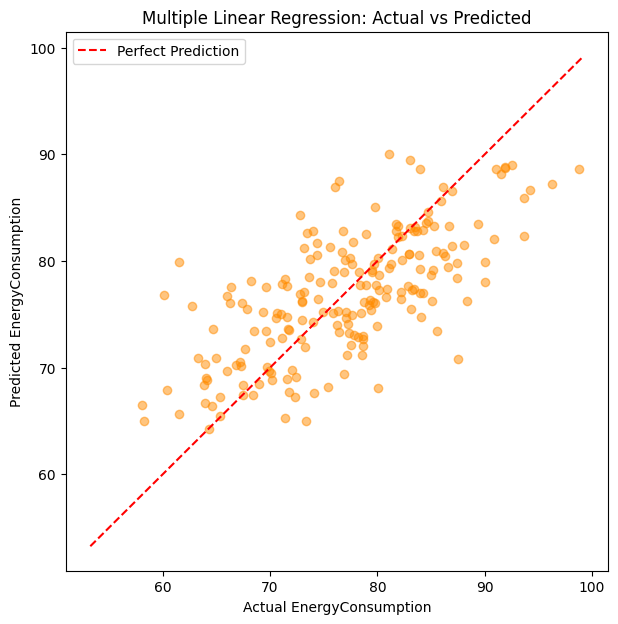

In [93]:
# Multi-variable regression should perform at least as well, since it has access to more information

# ---- Visualize: Actual vs Predicted for the multi-variable model ----
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_multi, alpha=0.5, color='darkorange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual EnergyConsumption')
plt.ylabel('Predicted EnergyConsumption')
plt.title('Multiple Linear Regression: Actual vs Predicted')
plt.legend()
plt.show()


In [94]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

# ---- Sample labeled dataset: spam vs ham (legitimate) messages ----
messages = [
    ("Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!", "spam"),
    ("URGENT: Your account has been suspended. Verify your details immediately to avoid closure.", "spam"),
    ("You have been selected for a free cruise trip. Call now to claim your prize!", "spam"),
    ("WINNER!! As a valued customer you have been selected to receive a cash reward.", "spam"),
    ("Get cheap loans approved instantly, no credit check required. Apply now!", "spam"),
    ("FREE entry into our weekly draw for a brand new iPhone. Text WIN to 80085.", "spam"),
    ("Your loan of $5000 has been approved. Click the link to receive funds today.", "spam"),
    ("Limited time offer! Buy one get one free on all products, click to shop now.", "spam"),
    ("You have won a lottery of 1 million dollars, reply with your bank details.", "spam"),
    ("Claim your free vacation package now, limited slots available!", "spam"),
    ("Earn $500 a day working from home, no experience needed, sign up now.", "spam"),
    ("Your prize money is waiting, click the link below to receive it instantly.", "spam"),
    ("Hot singles in your area are waiting to chat with you tonight!", "spam"),
    ("This is your final notice, your subscription will be cancelled unless you act now.", "spam"),
    ("Congratulations, you are pre-approved for a platinum credit card with 0% interest.", "spam"),
    ("Reminder: Your account password will expire soon, click here to reset it.", "spam"),
    ("You've been chosen to test our new product for free, just pay shipping.", "spam"),
    ("Double your income in just 2 weeks with this simple investment trick.", "spam"),
    ("Act now to receive a special discount only available for the next hour.", "spam"),
    ("Your package could not be delivered, click here to reschedule delivery.", "spam"),
    ("Hey, are we still on for lunch tomorrow at noon?", "ham"),
    ("Can you send me the meeting notes from yesterday's call?", "ham"),
    ("Don't forget to pick up milk and eggs on your way home.", "ham"),
    ("Happy birthday! Hope you have a wonderful day with your family.", "ham"),
    ("The project deadline has been moved to next Friday, please plan accordingly.", "ham"),
    ("Thanks for helping me move last weekend, I really appreciate it.", "ham"),
    ("Let's catch up over coffee sometime this week if you're free.", "ham"),
    ("I attached the report you asked for, let me know if you need edits.", "ham"),
    ("Mom said dinner will be ready by 7, come home soon.", "ham"),
    ("Great job on the presentation today, the client seemed impressed.", "ham"),
    ("Can we reschedule our meeting to 3pm instead of 2pm?", "ham"),
    ("I'll be a bit late to class today, traffic is really bad.", "ham"),
    ("Please review the attached document before our call tomorrow.", "ham"),
    ("Are you coming to the gym this evening or should I go alone?", "ham"),
    ("The flight got delayed by two hours, I'll update you when I land.", "ham"),
    ("Thanks for the birthday wishes, means a lot to me.", "ham"),
    ("Let me know what time works for you this weekend.", "ham"),
    ("I finished the assignment, sending it over to you now.", "ham"),
    ("Can you pick me up from the station at 6pm?", "ham"),
    ("Looking forward to seeing everyone at the reunion next month.", "ham"),
]

spam_df = pd.DataFrame(messages, columns=['message', 'label'])
print(spam_df['label'].value_counts())
spam_df.head()


label
spam    20
ham     20
Name: count, dtype: int64


,message,label
0,Congratulations! You've won a $1000 Walmart gi...,spam
1,URGENT: Your account has been suspended. Verif...,spam
2,You have been selected for a free cruise trip....,spam
3,WINNER!! As a valued customer you have been se...,spam
4,"Get cheap loans approved instantly, no credit ...",spam


In [96]:
# ---- Prepare features (text) and target (label) ----
X_text = spam_df['message']
y_label = spam_df['label'].map({'ham': 0, 'spam': 1})   # encode: ham=0, spam=1

X_train_txt, X_test_txt, y_train_lbl, y_test_lbl = train_test_split(
    X_text, y_label, test_size=0.25, random_state=42, stratify=y_label
)

In [98]:
# ---- Convert text into numeric features using TF-IDF ----
# TF-IDF gives higher weight to words that are frequent in a message but rare across all messages
# (good at highlighting spam-specific words like "free", "winner", "click")
vectorizer = TfidfVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train_txt)
X_test_vec  = vectorizer.transform(X_test_txt)   # transform only, don't re-fit on test data

print("Vocabulary size:", len(vectorizer.vocabulary_))


Vocabulary size: 153


In [99]:
# ---- Train the Logistic Regression classifier ----
log_model = LogisticRegression()
log_model.fit(X_train_vec, y_train_lbl)

y_pred_lbl = log_model.predict(X_test_vec)


In [100]:
# ---- Evaluate using classification performance metrics ----
print("Accuracy :", accuracy_score(y_test_lbl, y_pred_lbl))
print("Precision:", precision_score(y_test_lbl, y_pred_lbl))   # of predicted spam, how much was really spam
print("Recall   :", recall_score(y_test_lbl, y_pred_lbl))      # of actual spam, how much did we catch
print("F1-score :", f1_score(y_test_lbl, y_pred_lbl))          # balance of precision & recall
print()
print(classification_report(y_test_lbl, y_pred_lbl, target_names=['ham', 'spam']))

Accuracy : 0.8
Precision: 0.8
Recall   : 0.8
F1-score : 0.8

              precision    recall  f1-score   support

         ham       0.80      0.80      0.80         5
        spam       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10



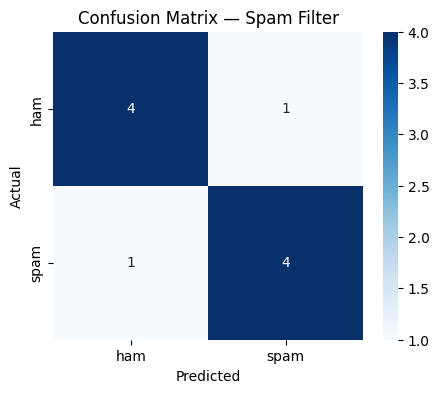

In [101]:
# ---- Confusion matrix visualization ----
cm = confusion_matrix(y_test_lbl, y_pred_lbl)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Spam Filter')
plt.show()



In [102]:
# ---- Try it on a new, unseen message ----
def predict_spam(message_text):
    vec = vectorizer.transform([message_text])
    prediction = log_model.predict(vec)[0]
    probability = log_model.predict_proba(vec)[0][1]   # probability of being spam
    label = 'SPAM' if prediction == 1 else 'HAM'
    print(f"Message : {message_text}")
    print(f"Result  : {label} (spam probability: {probability:.2%})")

predict_spam("Claim your free reward now by clicking this link!")
predict_spam("Hey, can you send me the file from class today?")

Message : Claim your free reward now by clicking this link!
Result  : SPAM (spam probability: 60.95%)
Message : Hey, can you send me the file from class today?
Result  : HAM (spam probability: 40.57%)
